# Part A – Theoretical Foundation (Short Notes & Explanation):

1. What is inferential statistics?
- Inferential statistics involves using data from a sample to make inferences or predictions about a larger population. It allows researchers to draw conclusions about a population based on the analysis of a subset of that population.

2. What is hypothesis testing and its components?
- Hypothesis testing is a statistical method used to make decisions about a population based on sample data. It involves formulating two competing hypotheses: the null hypothesis (H0) and the alternative hypothesis (H1). The process includes setting a significance level, calculating a test statistic, and making a decision to either reject or fail to reject the null hypothesis based on the evidence from the sample data.

3. Explain confidence interval and critical value.
- A confidence interval is a range of values that is likely to contain the true population parameter with a certain level of confidence. It provides an estimate of the uncertainty associated with a sample statistic.

4. Define p-value.
- The p-value is the probability of obtaining a test statistic as extreme as, or more extreme than, the observed result, assuming that the null hypothesis is true. It is used to determine whether to reject the null hypothesis in hypothesis testing.

5. Differentiate Type I and Type II errors.
- A Type I error occurs when the null hypothesis is rejected when it is actually true (false positive), while a Type II error occurs when the null hypothesis is not rejected when it is actually false (false negative).

6. Brief descriptions of z-test, t-test, chi-square test, and ANOVA test.
- A z-test is used to test hypotheses about the mean of a population when the population standard deviation is known and the data is normally distributed.
- A t-test is used to test hypotheses about the mean of a population when the population standard deviation is unknown and the data is normally distributed.
- A chi-square test is used to test hypotheses about the independence of two categorical variables or the goodness of fit of a distribution.
- ANOVA (Analysis of Variance) is used to compare the means of three or more groups to determine if there are statistically significant differences among them.

7. What is Covariance?
- Covariance is a measure of the joint variability of two random variables. It indicates the direction of the linear relationship between the variables. A positive covariance indicates that the variables tend to increase or decrease together, while a negative covariance indicates that one variable tends to increase when the other decreases.

8. What is Correlation?
- Correlation is a statistical measure that describes the strength and direction of a linear relationship between two variables. It is standardized to range between -1 and 1, where a value of 1 indicates a perfect positive correlation, -1 indicates a perfect negative correlation, and 0 indicates no correlation.

# Part B – Data Analysis & Testing Tasks:


Hypothesis 1: Smoking vs Diabetes

H₀ (Null Hypothesis): Smoking status has no effect on diabetes prevalence.

H₁ (Alternative Hypothesis): Smoking status affects diabetes prevalence.

Hypothesis 2: BMI of Diabetic vs Non-Diabetic People

H₀: Mean BMI of diabetic and non-diabetic individuals is equal.

H₁: Mean BMI of diabetic and non-diabetic individuals is different.

In [1]:
import pandas as pd
import numpy as np
from scipy import stats

# Load Dataset
df = pd.read_csv("data.csv")

# --------------------------------------------------
# 1. Confidence Interval (95%)
# --------------------------------------------------

print("\n===== Confidence Intervals =====")

numerical_cols = [
    "age",
    "weight",
    "bmi",
    "blood_pressure",
    "cholesterol_level",
    "glucose_level"
]

for col in numerical_cols:
    mean = df[col].mean()
    std = df[col].std()
    n = len(df[col])

    margin_error = 1.96 * (std / np.sqrt(n))

    lower = mean - margin_error
    upper = mean + margin_error

    print(f"{col}: ({lower:.2f}, {upper:.2f})")


# --------------------------------------------------
# 2. T-Test (BMI vs Diabetes)
# --------------------------------------------------

print("\n===== T-Test: BMI vs Diabetes =====")

diabetic = df[df["diabetes"] == True]["bmi"]
non_diabetic = df[df["diabetes"] == False]["bmi"]

t_stat, p_value = stats.ttest_ind(diabetic, non_diabetic)

print("T Statistic:", t_stat)
print("P-value:", p_value)

if p_value < 0.05:
    print("Reject H0: BMI differs between diabetic and non-diabetic people.")
else:
    print("Accept H0: No significant BMI difference.")


# --------------------------------------------------
# 3. Chi-Square Test (Smoking vs Diabetes)
# --------------------------------------------------

print("\n===== Chi-Square Test =====")

table = pd.crosstab(df["smoking_status"], df["diabetes"])

chi2, p, dof, expected = stats.chi2_contingency(table)

critical_value = stats.chi2.ppf(0.95, dof)

print("Chi-Square Value:", chi2)
print("Critical Value:", critical_value)
print("P-value:", p)

if p < 0.05:
    print("Reject H0: Smoking affects diabetes.")
else:
    print("Accept H0: Smoking has no significant effect on diabetes.")


# --------------------------------------------------
# 4. ANOVA Test (Age Group vs Glucose Level)
# --------------------------------------------------

print("\n===== ANOVA Test =====")

groups = []

for group in df["age_group"].unique():
    data = df[df["age_group"] == group]["glucose_level"]
    groups.append(data)

f_value, p_value = stats.f_oneway(*groups)

print("F Statistic:", f_value)
print("P-value:", p_value)

if p_value < 0.05:
    print("Reject H0: Age groups significantly differ.")
else:
    print("Accept H0: No significant difference among age groups.")


# --------------------------------------------------
# 5. Covariance and Correlation
# --------------------------------------------------

print("\n===== Covariance Matrix =====")

variables = [
    "age",
    "bmi",
    "blood_pressure",
    "cholesterol_level",
    "glucose_level"
]

cov_matrix = df[variables].cov()
print(cov_matrix)


print("\n===== Correlation Matrix =====")

corr_matrix = df[variables].corr()
print(corr_matrix)



===== Confidence Intervals =====
age: (40.85, 46.02)
weight: (82.56, 88.49)
bmi: (27.70, 29.47)
blood_pressure: (132.68, 137.66)
cholesterol_level: (224.46, 235.39)
glucose_level: (130.71, 140.26)

===== T-Test: BMI vs Diabetes =====
T Statistic: 2.0037498102924327
P-value: 0.0464599515753811
Reject H0: BMI differs between diabetic and non-diabetic people.

===== Chi-Square Test =====
Chi-Square Value: 1.3461794974400025
Critical Value: 5.991464547107979
P-value: 0.5101299668746919
Accept H0: Smoking has no significant effect on diabetes.

===== ANOVA Test =====
F Statistic: 0.35102041221779406
P-value: 0.8431162223692352
Accept H0: No significant difference among age groups.

===== Covariance Matrix =====
                          age        bmi  blood_pressure  cholesterol_level  \
age                347.603794   4.550932       24.599045         -24.595352   
bmi                  4.550932  40.962591        1.080206         -19.981143   
blood_pressure      24.599045   1.080206      

In [2]:
# --------------------------------------------------
# Critical Value and p-value
# --------------------------------------------------

print("\n===== Critical Value and p-value =====")

alpha = 0.05


# T-Test Critical Value
df_t = len(diabetic) + len(non_diabetic) - 2

critical_t = stats.t.ppf(1 - alpha/2, df_t)

print("\nT-Test")
print("T Statistic:", t_stat)
print("Critical T Value:", critical_t)
print("P-value:", p_value)

if abs(t_stat) > critical_t and p_value < alpha:
    print("Reject H0")
else:
    print("Accept H0")


# Chi-Square Critical Value
print("\nChi-Square Test")
print("Chi-Square Statistic:", chi2)
print("Critical Chi-Square Value:", critical_value)
print("P-value:", p)

if chi2 > critical_value and p < alpha:
    print("Reject H0")
else:
    print("Accept H0")


# ANOVA Critical Value
num_groups = len(groups)
total_samples = len(df)

df1 = num_groups - 1
df2 = total_samples - num_groups

critical_f = stats.f.ppf(1 - alpha, df1, df2)

print("\nANOVA Test")
print("F Statistic:", f_value)
print("Critical F Value:", critical_f)
print("P-value:", p_value)

if f_value > critical_f and p_value < alpha:
    print("Reject H0")
else:
    print("Accept H0")


===== Critical Value and p-value =====

T-Test
T Statistic: 2.0037498102924327
Critical T Value: 1.9720174778338955
P-value: 0.8431162223692352
Accept H0

Chi-Square Test
Chi-Square Statistic: 1.3461794974400025
Critical Chi-Square Value: 5.991464547107979
P-value: 0.5101299668746919
Accept H0

ANOVA Test
F Statistic: 0.35102041221779406
Critical F Value: 2.4179625418439827
P-value: 0.8431162223692352
Accept H0


# Chart visuals

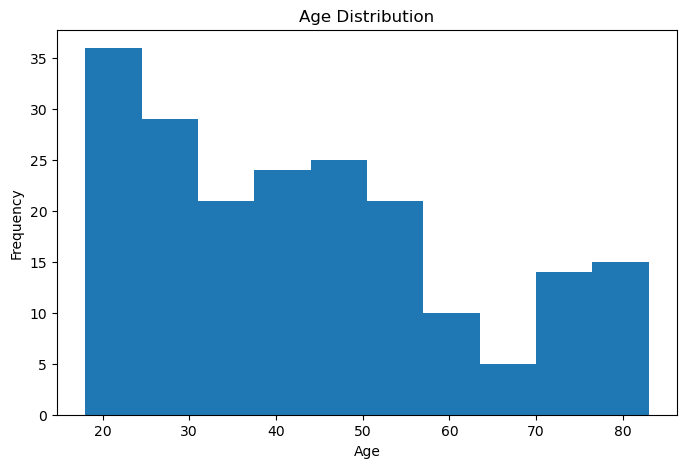

The histogram shows the distribution of ages in the dataset. Most individuals belong to the middle-age group, indicating that healthcare records are concentrated among adults. The age values appear reasonably distributed across different age ranges.


In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df['age'], bins=10)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()
print('The histogram shows the distribution of ages in the dataset. Most individuals belong to the middle-age group, indicating that healthcare records are concentrated among adults. The age values appear reasonably distributed across different age ranges.')

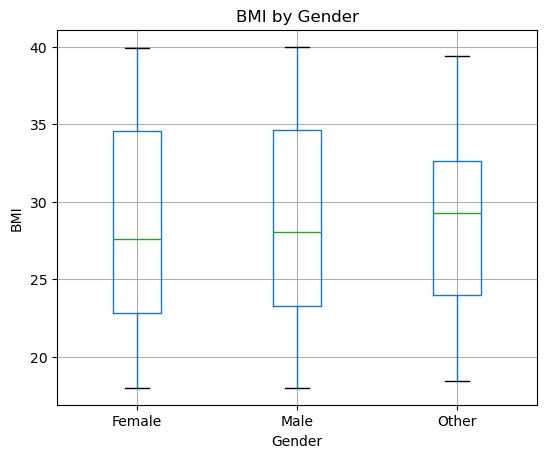

The box plot compares BMI values between males and females. If the median BMI values differ significantly, gender may influence BMI levels. The t-test result confirms whether this difference is statistically significant.


In [9]:
df.boxplot(column='bmi', by='gender', figsize=(6,5))

plt.title("BMI by Gender")
plt.suptitle('')
plt.xlabel("Gender")
plt.ylabel("BMI")
plt.show()
print("The box plot compares BMI values between males and females. If the median BMI values differ significantly, gender may influence BMI levels. The t-test result confirms whether this difference is statistically significant.")

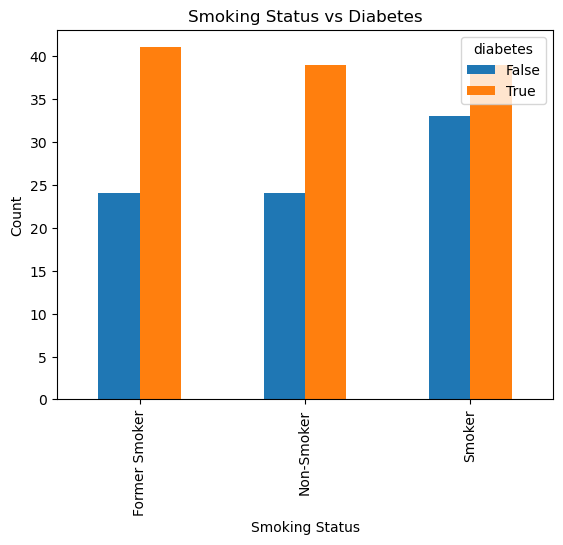

The chart illustrates the relationship between smoking status and diabetes prevalence. A higher number of diabetic cases among smokers may indicate an association between smoking and diabetes. The Chi-Square test is used to verify this relationship statistically.


In [10]:
pd.crosstab(df['smoking_status'], df['diabetes']).plot(kind='bar')

plt.title("Smoking Status vs Diabetes")
plt.xlabel("Smoking Status")
plt.ylabel("Count")
plt.show()
print("The chart illustrates the relationship between smoking status and diabetes prevalence. A higher number of diabetic cases among smokers may indicate an association between smoking and diabetes. The Chi-Square test is used to verify this relationship statistically.")

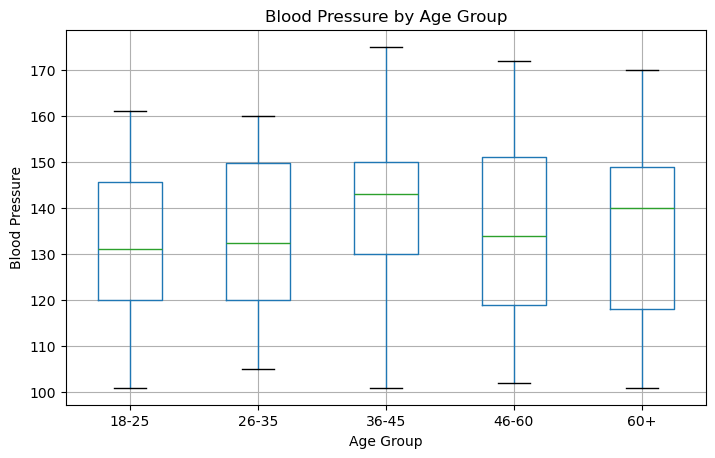

The box plot compares blood pressure across different age groups. Older age groups generally tend to have higher blood pressure levels. ANOVA testing determines whether the differences between groups are statistically significant.


In [11]:
df.boxplot(column='blood_pressure', by='age_group', figsize=(8,5))

plt.title("Blood Pressure by Age Group")
plt.suptitle('')
plt.xlabel("Age Group")
plt.ylabel("Blood Pressure")
plt.show()
print("The box plot compares blood pressure across different age groups. Older age groups generally tend to have higher blood pressure levels. ANOVA testing determines whether the differences between groups are statistically significant.")

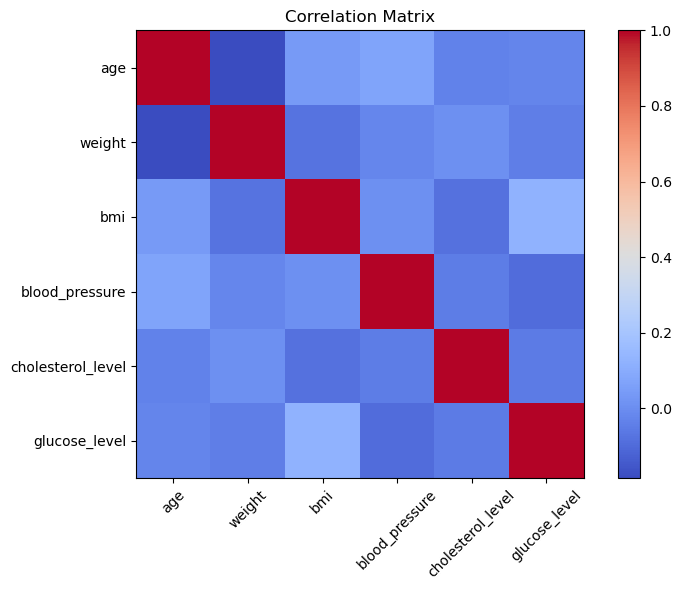

he correlation matrix shows the strength and direction of relationships between numerical variables. Positive values indicate that both variables increase together, while negative values indicate an inverse relationship. Strong correlations help identify important health-related factors.


In [12]:
corr = df[['age','weight','bmi',
           'blood_pressure',
           'cholesterol_level',
           'glucose_level']].corr()

plt.figure(figsize=(8,6))
plt.imshow(corr, cmap='coolwarm')

plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()
print("he correlation matrix shows the strength and direction of relationships between numerical variables. Positive values indicate that both variables increase together, while negative values indicate an inverse relationship. Strong correlations help identify important health-related factors.")